In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.preprocessing import OrdinalEncoder ,OneHotEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report , confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [104]:
train = pd.read_csv("customer_churn_dataset-training-master.csv")

test = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [3]:
train.head(3)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0


#### EDA

In [4]:
train.shape

(440833, 12)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [6]:
train.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
train.duplicated().sum()

np.int64(0)

In [8]:
train.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [9]:
train.dropna(inplace=True)

In [10]:
train.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

#### Concating Two Dataframes To split it into (Train , Val , Test)

In [11]:
df = pd.concat([train,test],axis=0)

In [12]:
df.head(3)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0


In [13]:
df.shape

(505206, 12)

In [14]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

#### Droping non-usefull columns

In [15]:
df.drop("CustomerID",axis= 1 , inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                505206 non-null  float64
 1   Gender             505206 non-null  object 
 2   Tenure             505206 non-null  float64
 3   Usage Frequency    505206 non-null  float64
 4   Support Calls      505206 non-null  float64
 5   Payment Delay      505206 non-null  float64
 6   Subscription Type  505206 non-null  object 
 7   Contract Length    505206 non-null  object 
 8   Total Spend        505206 non-null  float64
 9   Last Interaction   505206 non-null  float64
 10  Churn              505206 non-null  float64
dtypes: float64(8), object(3)
memory usage: 46.3+ MB


In [17]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [18]:
df.describe(include="object")

,Gender,Subscription Type,Contract Length
count,505206,505206,505206
unique,2,3,3
top,Male,Standard,Annual
freq,280273,170630,198608


In [19]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("---------------------------------------")

Age
[30. 65. 55. 58. 23. 51. 39. 64. 29. 52. 22. 48. 24. 49. 19. 47. 42. 57.
 27. 59. 21. 60. 35. 18. 56. 20. 63. 25. 28. 32. 38. 37. 31. 53. 41. 33.
 26. 36. 44. 34. 61. 40. 45. 46. 54. 43. 50. 62.]
---------------------------------------
Gender
['Female' 'Male']
---------------------------------------
Tenure
[39. 49. 14. 38. 32. 33. 37. 12.  3. 18. 21. 41. 35.  4. 56. 44. 15. 55.
 43. 52. 26.  2. 29. 59. 40. 51. 53. 24. 30.  6. 28. 17. 60.  7. 34. 10.
  5. 45. 54. 58. 25. 13. 47. 31. 22. 19. 23.  1.  8. 46. 16. 50. 48. 11.
 42. 27.  9. 20. 57. 36.]
---------------------------------------
Usage Frequency
[14.  1.  4. 21. 20. 25. 12.  8.  5.  9.  6. 17. 23. 13. 16. 27.  2. 28.
 29. 15. 24.  3. 22. 26. 30.  7. 11. 18. 19. 10.]
---------------------------------------
Support Calls
[ 5. 10.  6.  7.  9.  3.  4.  2.  0.  1.  8.]
---------------------------------------
Payment Delay
[18.  8.  7. 26. 16. 15.  4. 11. 30. 25. 13. 22.  5. 14.  3. 10. 28.  2.
  6. 27. 12. 29. 17. 24.  9. 23. 21. 

In [20]:
df.isna().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [21]:
num_col = df.select_dtypes(include="number").columns

cat_col = df.select_dtypes(include="object").columns

#### Error detection

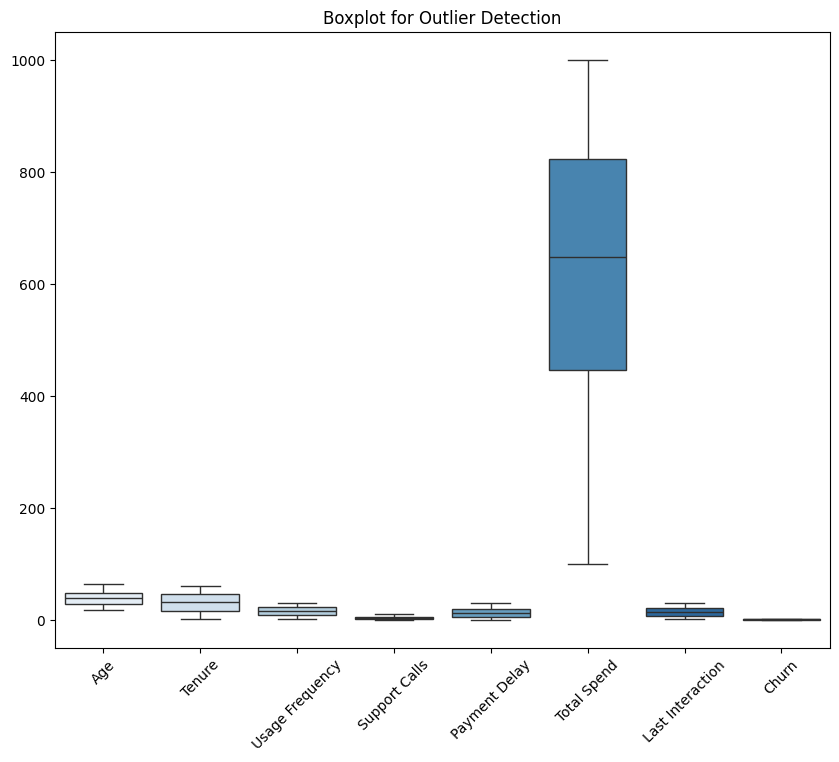

In [22]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df[num_col] , palette='Blues')

plt.title('Boxplot for Outlier Detection')
plt.xticks(rotation = 45)
plt.show()

As we Saw There Is No Outliers

### Univariate Analysis

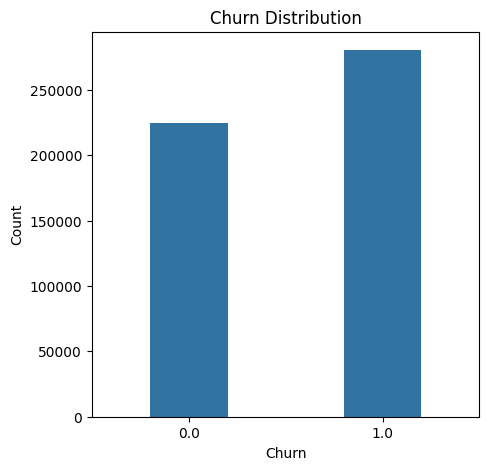

In [23]:
plt.figure(figsize=(5, 5))

sns.countplot(
    data=df,
    x="Churn" ,width =.4
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

This Distribution Reflect That Data Imblanced and more People Leave This Business (Churn)

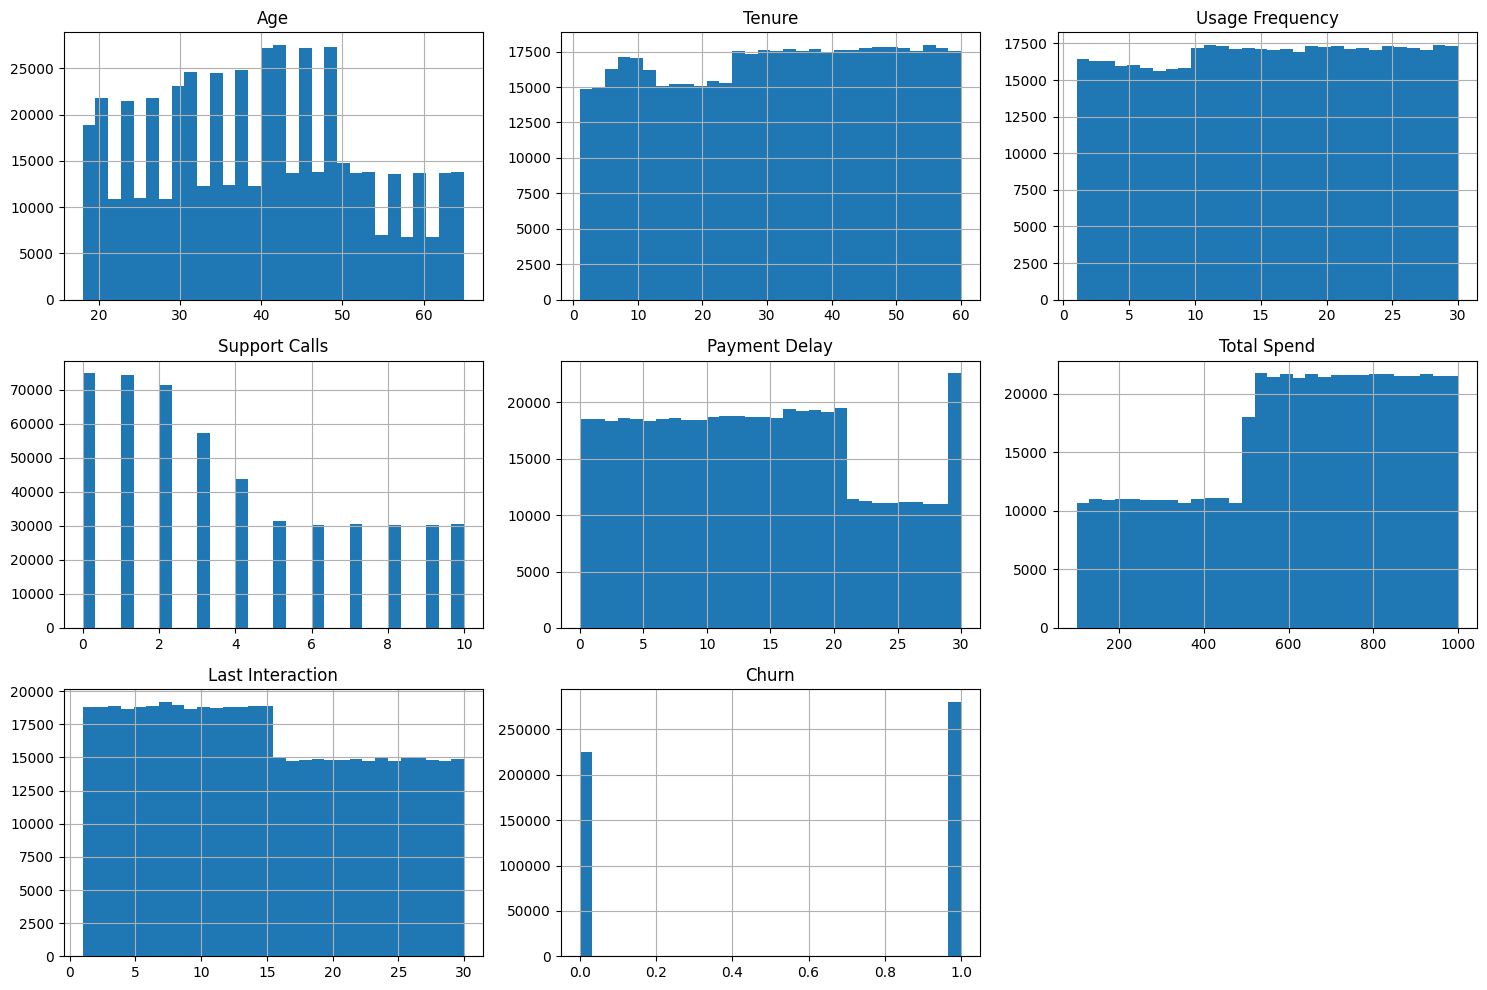

In [24]:
df[num_col].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

Gender               Axes(0.125,0.11;0.775x0.77)
Subscription Type    Axes(0.125,0.11;0.775x0.77)
Contract Length      Axes(0.125,0.11;0.775x0.77)
dtype: object

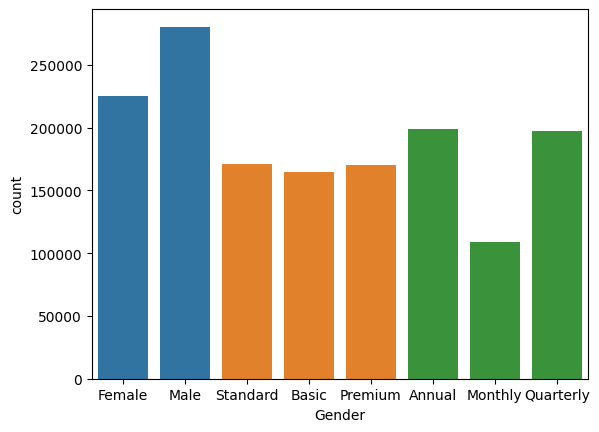

In [25]:
df[cat_col].apply(lambda x: sns.countplot(x=x))

 We observed that male have a higher churn rate than female 

 Customers with monthly contracts have the highest churn rate 

### Bivariate Analysis

<Axes: xlabel='Churn', ylabel='Tenure'>

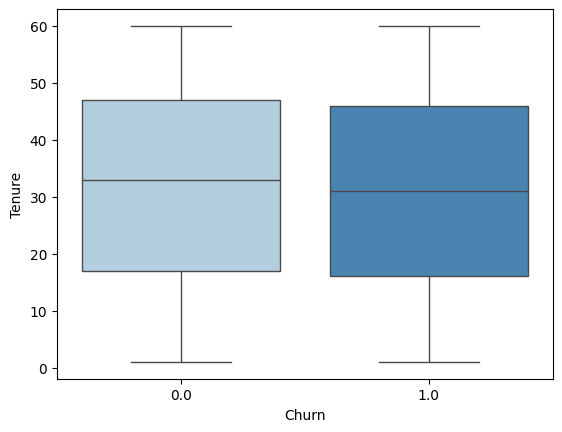

In [26]:
sns.boxplot(data=df, x='Churn', y='Tenure', palette="Blues")

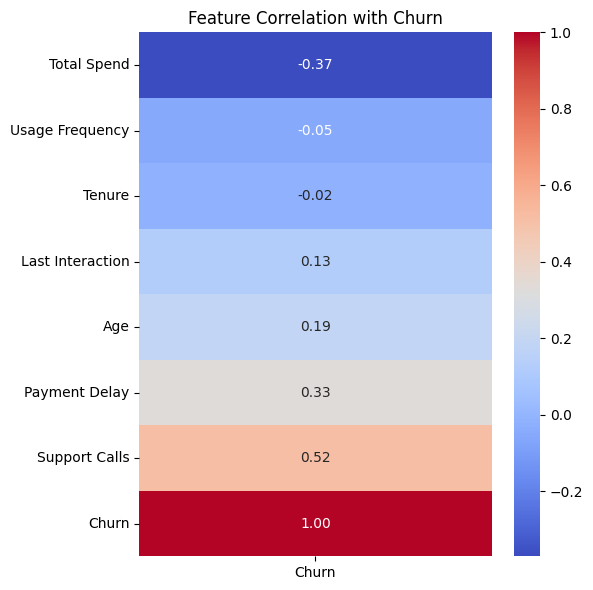

In [27]:
plt.figure(figsize=(6, 6))

corr = df[num_col].corr()['Churn'].sort_values().to_frame()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation with Churn")
plt.tight_layout()
plt.show()

#### Multivirate Analysis

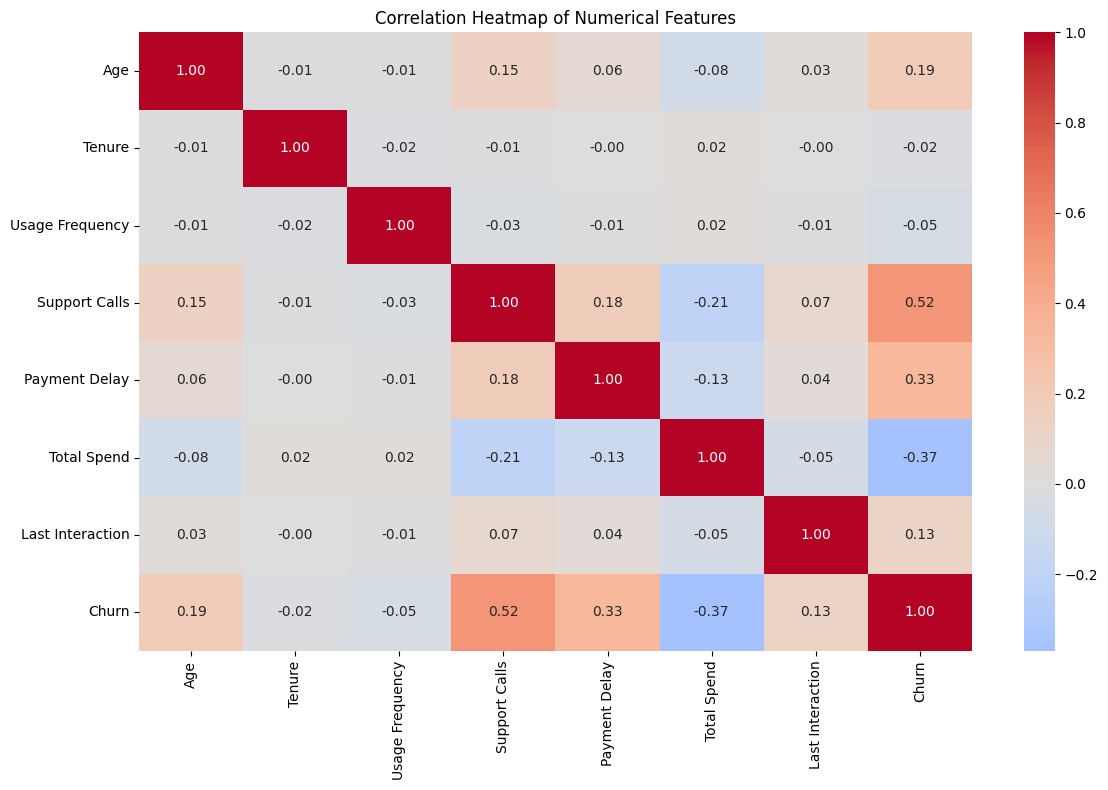

In [28]:
plt.figure(figsize=(12, 8))

corr = df[num_col].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#### i apply 2 ways of encoding:
 1. oneHotEncoding > Gender beacause it is nominal
 2. Ordinal Encoder > Subscription Type , Contract Length because they Ordinal

In [29]:
df_encoded = df.copy()

In [30]:
ohe = OneHotEncoder(
    drop='first',
    sparse_output=False
)

In [31]:
gender_encoded = ohe.fit_transform(df_encoded[['Gender']])

In [32]:
gender_df = pd.DataFrame(
    gender_encoded,
    columns=ohe.get_feature_names_out(['Gender']),
    index=df_encoded.index
)

In [33]:
gender_df

,Gender_Male
0,0.0
1,0.0
2,0.0
3,1.0
4,1.0
...,...
64369,0.0
64370,1.0
64371,1.0
64372,0.0


In [34]:
df_encoded = pd.concat([df_encoded.drop('Gender', axis=1), gender_df], axis=1)

In [35]:
df_encoded

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Gender_Male
0,30.0,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,0.0
1,65.0,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,0.0
2,55.0,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,0.0
3,58.0,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,1.0
4,23.0,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
64369,45.0,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0,0.0
64370,37.0,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0,1.0
64371,25.0,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0,1.0
64372,50.0,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0,0.0


In [36]:
ordinal_cols = ['Subscription Type', 'Contract Length']

In [37]:
oe = OrdinalEncoder(
    categories=[
        ['Basic', 'Standard', 'Premium'],        
        ['Monthly', 'Quarterly', 'Annual']       
    ]
)

In [38]:
df_encoded[ordinal_cols] = oe.fit_transform(df_encoded[ordinal_cols])

In [39]:
df_encoded

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Gender_Male
0,30.0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0,0.0
1,65.0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0,0.0
2,55.0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0,0.0
3,58.0,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0,1.0
4,23.0,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
64369,45.0,33.0,12.0,6.0,21.0,0.0,1.0,947.0,14.0,1.0,0.0
64370,37.0,6.0,1.0,5.0,22.0,1.0,2.0,923.0,9.0,1.0,1.0
64371,25.0,39.0,14.0,8.0,30.0,2.0,0.0,327.0,20.0,1.0,1.0
64372,50.0,18.0,19.0,7.0,22.0,1.0,0.0,540.0,13.0,1.0,0.0


In [40]:
X = df_encoded.drop('Churn' , axis= 1)
y = df_encoded['Churn']

In [41]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [42]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

In [43]:
X_train.shape

(353846, 10)

In [44]:
y_train.shape

(353846,)

In [45]:
X_val.shape

(75579, 10)

In [46]:
y_val.shape

(75579,)

In [47]:
X_test.shape

(75781, 10)

In [48]:
y_test.shape

(75781,)

#### Apply Scaling To Improve Distance Based Models

In [49]:
df_encoded.head(1)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Gender_Male
0,30.0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0,0.0


In [50]:
scaled_col = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction']

In [51]:
scaler = StandardScaler()

In [52]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [53]:
X_train[scaled_col] = scaler.fit_transform(X_train[scaled_col])

In [54]:
X_val[scaled_col] = scaler.transform(X_val[scaled_col])

In [55]:
X_test[scaled_col] = scaler.transform(X_test[scaled_col])

#### I Try To Balance Clsaases Of this Data

In [56]:
rus = RandomUnderSampler(sampling_strategy='auto',
    random_state=42
)

In [57]:
rus

,sampling_strategy,'auto'
,random_state,42
,replacement,False


In [58]:
X_train, y_train = rus.fit_resample(X_train, y_train)


In [59]:
X_train

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Gender_Male
254058,-1.318582,1.313450,0.147011,-0.904167,-0.176343,2.0,1.0,-0.237367,-1.000076,1.0
271061,-1.476397,-1.007941,0.959094,-1.223290,0.533546,2.0,1.0,0.382736,1.090779,1.0
31518,1.522093,0.442928,-1.129119,0.372324,-0.412973,0.0,2.0,0.118294,1.439255,0.0
409181,-1.476397,-0.079385,0.263023,-0.585045,-0.176343,2.0,1.0,1.363594,0.858462,1.0
411917,-0.371690,-0.311524,0.379035,-0.904167,0.770176,0.0,2.0,0.962773,-1.580869,0.0
...,...,...,...,...,...,...,...,...,...,...
120050,1.443185,1.313450,0.959094,-1.223290,0.888491,1.0,1.0,-0.069196,-1.232394,1.0
114619,0.654109,-0.195454,1.539153,0.053201,0.651861,1.0,0.0,-0.484935,-1.116235,1.0
62848,1.206462,0.268824,-1.245131,1.329693,1.243436,1.0,2.0,1.169868,-0.883918,1.0
77616,0.890832,-1.414184,0.611058,-0.904167,0.533546,0.0,2.0,0.044928,-0.419283,1.0


In [60]:
y_train

254058    0.0
271061    0.0
31518     0.0
409181    0.0
411917    0.0
         ... 
120050    1.0
114619    1.0
62848     1.0
77616     1.0
148160    1.0
Name: Churn, Length: 314780, dtype: float64

#### Basic Models

In [61]:
Basic_models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [62]:
results = []

name → model name 

model → actual ML model object

Logistic Regression | Acc: 0.83
              precision    recall  f1-score   support

         0.0       0.78      0.85      0.82     33617
         1.0       0.87      0.81      0.84     41962

    accuracy                           0.83     75579
   macro avg       0.83      0.83      0.83     75579
weighted avg       0.83      0.83      0.83     75579



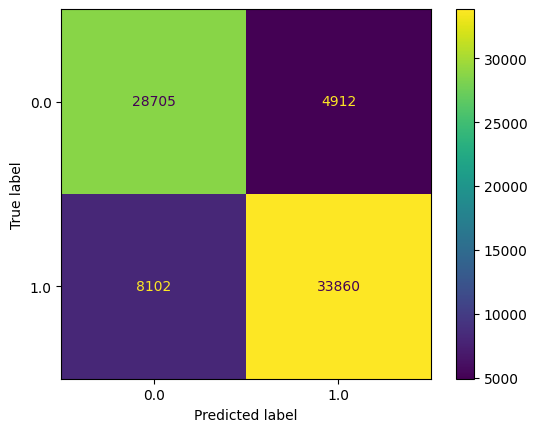

Naive Bayes | Acc: 0.87
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.85     33617
         1.0       0.90      0.85      0.88     41962

    accuracy                           0.87     75579
   macro avg       0.86      0.87      0.86     75579
weighted avg       0.87      0.87      0.87     75579



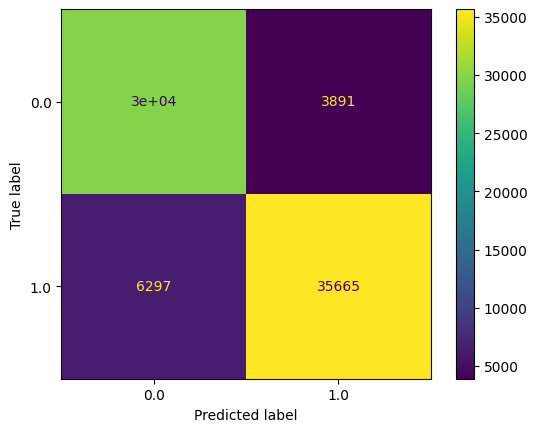

KNN | Acc: 0.89
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.88     33617
         1.0       0.90      0.90      0.90     41962

    accuracy                           0.89     75579
   macro avg       0.89      0.89      0.89     75579
weighted avg       0.89      0.89      0.89     75579



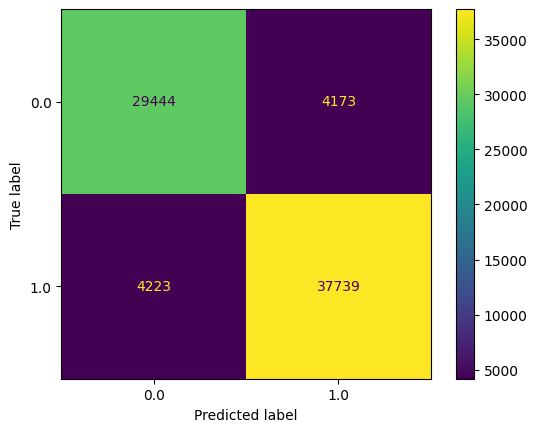

Decision Tree | Acc: 0.87
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86     33617
         1.0       0.90      0.86      0.88     41962

    accuracy                           0.87     75579
   macro avg       0.87      0.87      0.87     75579
weighted avg       0.87      0.87      0.87     75579



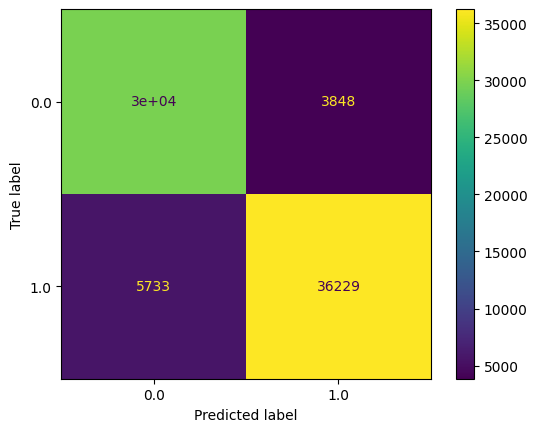

Random Forest | Acc: 0.94
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     33617
         1.0       0.90      1.00      0.95     41962

    accuracy                           0.94     75579
   macro avg       0.95      0.93      0.93     75579
weighted avg       0.94      0.94      0.94     75579



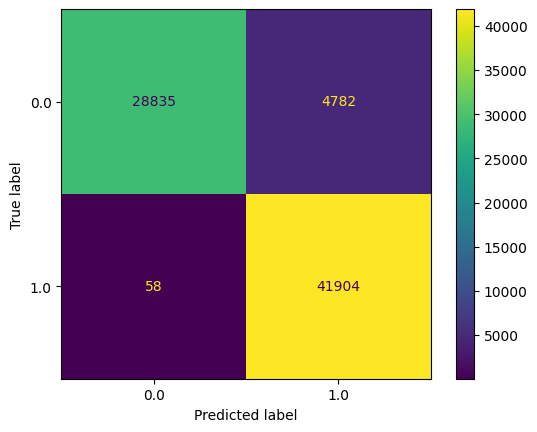

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.83,0.87,0.81,0.84
1,Naive Bayes,0.87,0.90,0.85,0.88
2,KNN,0.89,0.90,0.90,0.90
3,Decision Tree,0.87,0.90,0.86,0.88
4,Random Forest,0.94,0.90,1.00,0.95


In [63]:
results = []

for name, model in Basic_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    # Store metrics
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_val, y_pred), 2),
        "Precision": round(precision_score(y_val, y_pred), 2),
        "Recall": round(recall_score(y_val, y_pred), 2),
        "F1": round(f1_score(y_val, y_pred), 2)
    })

    # Print summary
    print(f"{name} | Acc: {accuracy_score(y_val, y_pred):.2f}")
    print(classification_report(y_val, y_pred))
    
    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()

# Final results table
results_df = pd.DataFrame(results)
results_df


#### Hyperparameter Tuning

In [64]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"],
        "max_iter": [200 ,500 ,1000]
    },
    "Naive Bayes": {
        
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },
    
    "Decision Tree": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 150],
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10]
    },
    
}

In [65]:
tuned_models = {}
tuned_results = []


Running GridSearchCV for Logistic Regression...
Logistic Regression | Acc: 0.83
              precision    recall  f1-score   support

         0.0       0.78      0.85      0.82     33617
         1.0       0.87      0.81      0.84     41962

    accuracy                           0.83     75579
   macro avg       0.83      0.83      0.83     75579
weighted avg       0.83      0.83      0.83     75579



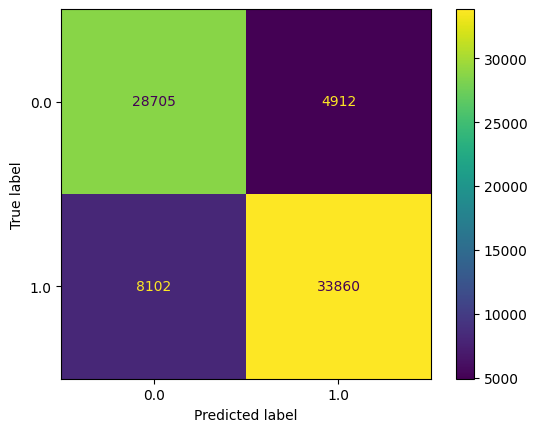

Running GridSearchCV for Naive Bayes...
Naive Bayes | Acc: 0.87
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.85     33617
         1.0       0.90      0.85      0.88     41962

    accuracy                           0.87     75579
   macro avg       0.86      0.87      0.86     75579
weighted avg       0.87      0.87      0.87     75579



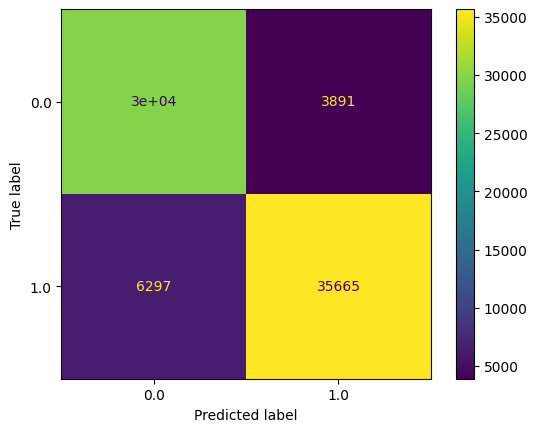

Running GridSearchCV for KNN...
KNN | Acc: 0.89
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88     33617
         1.0       0.90      0.91      0.90     41962

    accuracy                           0.89     75579
   macro avg       0.89      0.89      0.89     75579
weighted avg       0.89      0.89      0.89     75579



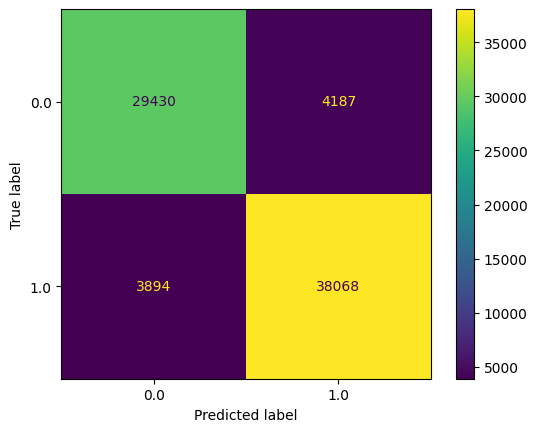

Running GridSearchCV for Decision Tree...
Decision Tree | Acc: 0.93
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     33617
         1.0       0.90      0.99      0.94     41962

    accuracy                           0.93     75579
   macro avg       0.94      0.93      0.93     75579
weighted avg       0.94      0.93      0.93     75579



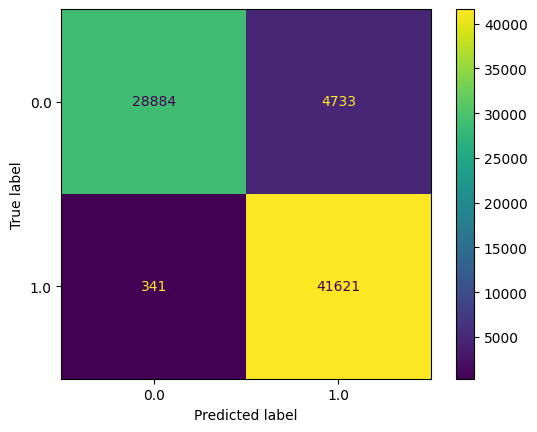

Running GridSearchCV for Random Forest...
Random Forest | Acc: 0.94
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     33617
         1.0       0.90      1.00      0.95     41962

    accuracy                           0.94     75579
   macro avg       0.95      0.93      0.93     75579
weighted avg       0.94      0.94      0.94     75579



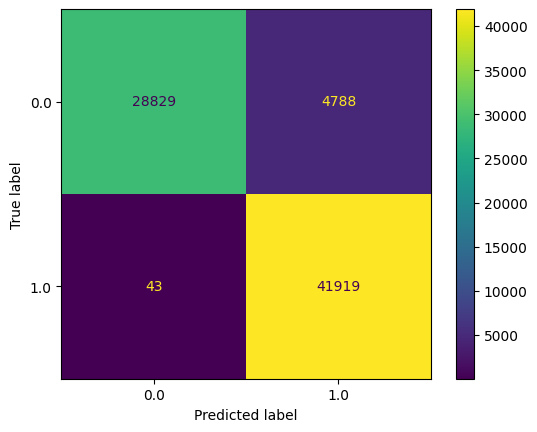

,Model,Accuracy,Precision,Recall,F1,Best_Params
0,Logistic Regression,0.83,0.87,0.81,0.84,"{'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}"
1,Naive Bayes,0.87,0.90,0.85,0.88,None
2,KNN,0.89,0.90,0.91,0.90,"{'n_neighbors': 9, 'weights': 'distance'}"
3,Decision Tree,0.93,0.90,0.99,0.94,"{'max_depth': 10, 'min_samples_split': 2}"
4,Random Forest,0.94,0.90,1.00,0.95,"{'max_depth': None, 'min_samples_split': 10, '..."


In [66]:
for name, model in Basic_models.items():
    print(f"Running GridSearchCV for {name}...")

    # Apply tuning if params exist
    if name in param_grids and param_grids[name]:
        grid = GridSearchCV(model, param_grids[name], scoring="f1", cv=5, n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params = grid.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = None

    # Store model
    tuned_models[name] = best_model

    # Predictions
    y_pred = best_model.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    tuned_results.append({
        "Model": name,
        "Accuracy": round(acc, 2),
        "Precision": round(prec, 2),
        "Recall": round(rec, 2),
        "F1": round(f1, 2),
        "Best_Params": best_params
    })

    # Output
    print(f"{name} | Acc: {acc:.2f}")
    print(classification_report(y_val, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()

# DataFrame
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df


#### Before & After Hyperparameter Tuning

In [68]:
all_models = pd.concat([results_df , tuned_results_df] , axis =0).sort_values('Model')
all_models


,Model,Accuracy,Precision,Recall,F1,Best_Params
3,Decision Tree,0.87,0.90,0.86,0.88,NaN
3,Decision Tree,0.93,0.90,0.99,0.94,"{'max_depth': 10, 'min_samples_split': 2}"
2,KNN,0.89,0.90,0.90,0.90,NaN
2,KNN,0.89,0.90,0.91,0.90,"{'n_neighbors': 9, 'weights': 'distance'}"
0,Logistic Regression,0.83,0.87,0.81,0.84,NaN
0,Logistic Regression,0.83,0.87,0.81,0.84,"{'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}"
1,Naive Bayes,0.87,0.90,0.85,0.88,NaN
1,Naive Bayes,0.87,0.90,0.85,0.88,None
4,Random Forest,0.94,0.90,1.00,0.95,NaN
4,Random Forest,0.94,0.90,1.00,0.95,"{'max_depth': None, 'min_samples_split': 10, '..."


#### Advanced Algorithims
[SVC , XGboost , Adaboost ]

In [72]:
from catboost import CatBoostClassifier

In [85]:
Advanced_models = {
    'AdaBoost':AdaBoostClassifier(),
    'Extratree':ExtraTreesClassifier(verbose= 0 ),
    'XGBoost':XGBClassifier(),
    'CatBoost' : CatBoostClassifier(verbose= 0)
}

AdaBoost | Acc: 0.85
              precision    recall  f1-score   support

         0.0       0.79      0.90      0.84     33617
         1.0       0.91      0.81      0.86     41962

    accuracy                           0.85     75579
   macro avg       0.85      0.85      0.85     75579
weighted avg       0.86      0.85      0.85     75579



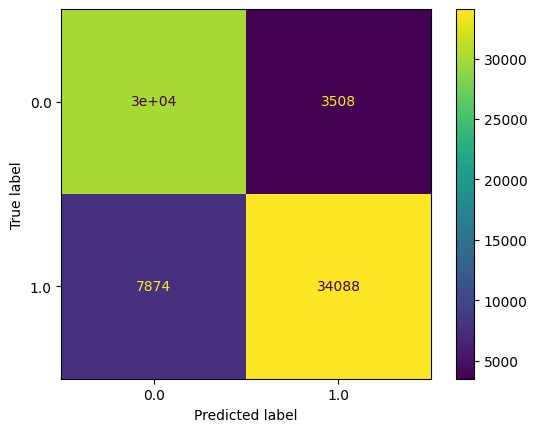

Extratree | Acc: 0.93
              precision    recall  f1-score   support

         0.0       0.98      0.86      0.91     33617
         1.0       0.90      0.98      0.94     41962

    accuracy                           0.93     75579
   macro avg       0.94      0.92      0.93     75579
weighted avg       0.93      0.93      0.93     75579



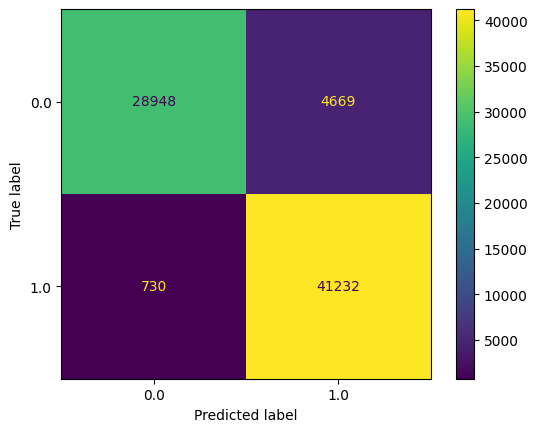

XGBoost | Acc: 0.93
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     33617
         1.0       0.90      0.99      0.94     41962

    accuracy                           0.93     75579
   macro avg       0.94      0.93      0.93     75579
weighted avg       0.94      0.93      0.93     75579



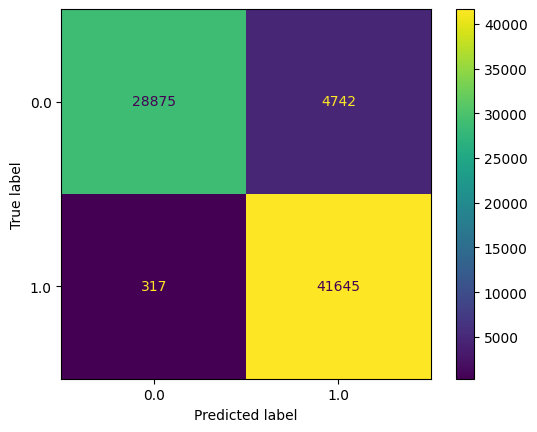

CatBoost | Acc: 0.93
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     33617
         1.0       0.90      0.99      0.94     41962

    accuracy                           0.93     75579
   macro avg       0.94      0.93      0.93     75579
weighted avg       0.94      0.93      0.93     75579



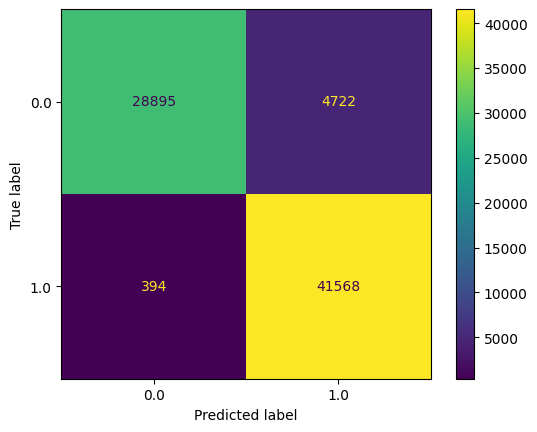

,Model,Accuracy,Precision,Recall,F1
0,AdaBoost,0.85,0.91,0.81,0.86
1,Extratree,0.93,0.90,0.98,0.94
2,XGBoost,0.93,0.90,0.99,0.94
3,CatBoost,0.93,0.90,0.99,0.94


In [86]:


Advanced_results = []

for name, model in Advanced_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    # calculate metrics once
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    # store results
    Advanced_results.append({
        "Model": name,
        "Accuracy": round(acc, 2),
        "Precision": round(prec, 2),
        "Recall": round(rec, 2),
        "F1": round(f1, 2)
    })

    # print output
    print(f"{name} | Acc: {acc:.2f}")
    print(classification_report(y_val, y_pred))

    # confusion matrix (simple way)
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()

# final table
Advanced_results = pd.DataFrame(Advanced_results)
Advanced_results

In [87]:
Final_results = pd.concat([all_models ,Advanced_results ] , axis = 0)

In [88]:
Final_results

,Model,Accuracy,Precision,Recall,F1,Best_Params
3,Decision Tree,0.87,0.90,0.86,0.88,NaN
3,Decision Tree,0.93,0.90,0.99,0.94,"{'max_depth': 10, 'min_samples_split': 2}"
2,KNN,0.89,0.90,0.90,0.90,NaN
2,KNN,0.89,0.90,0.91,0.90,"{'n_neighbors': 9, 'weights': 'distance'}"
0,Logistic Regression,0.83,0.87,0.81,0.84,NaN
0,Logistic Regression,0.83,0.87,0.81,0.84,"{'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}"
1,Naive Bayes,0.87,0.90,0.85,0.88,NaN
1,Naive Bayes,0.87,0.90,0.85,0.88,None
4,Random Forest,0.94,0.90,1.00,0.95,NaN
4,Random Forest,0.94,0.90,1.00,0.95,"{'max_depth': None, 'min_samples_split': 10, '..."


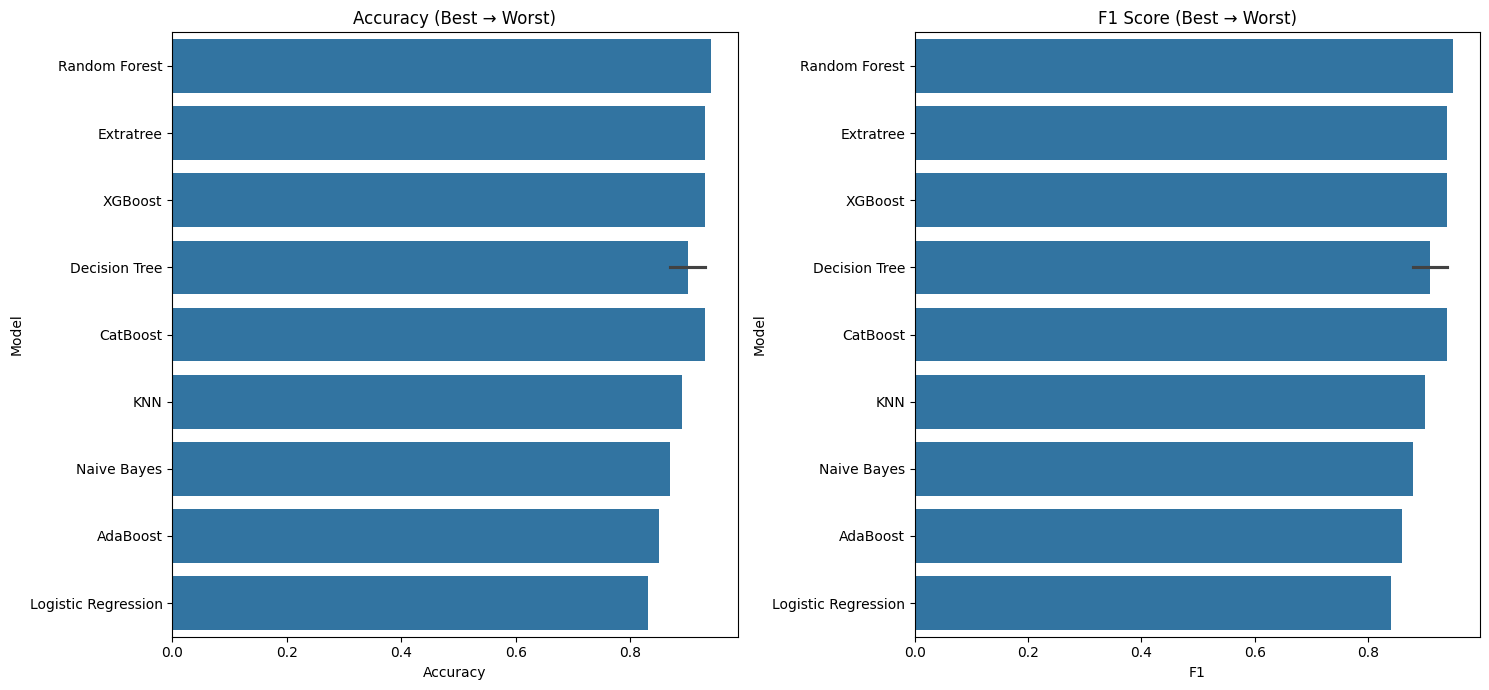

In [90]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.barplot(data=Final_results.sort_values("Accuracy", ascending=False),
            x="Accuracy", y="Model")
plt.title("Accuracy (Best → Worst)")

# F1 Score 
plt.subplot(1, 2, 2)
sns.barplot(data=Final_results.sort_values("F1", ascending=False),
            x="F1", y="Model")
plt.title("F1 Score (Best → Worst)")

plt.tight_layout()
plt.show()

### Getting Best Model Name

In [92]:
best_model_name = (
    Final_results
    .sort_values(by='F1', ascending=False)
    .iloc[0]['Model']
)
best_model_name

'Random Forest'

In [97]:
def get_model(name):
    all_models = {**Basic_models, **Advanced_models}

    if name in tuned_models:
        return tuned_models[name]   

    if name in all_models:
        return all_models[name]

    raise ValueError(f"Model '{name}' not found")

#### Feature Importance

I used hasattr() to dynamically check model capabilities and avoid runtime errors

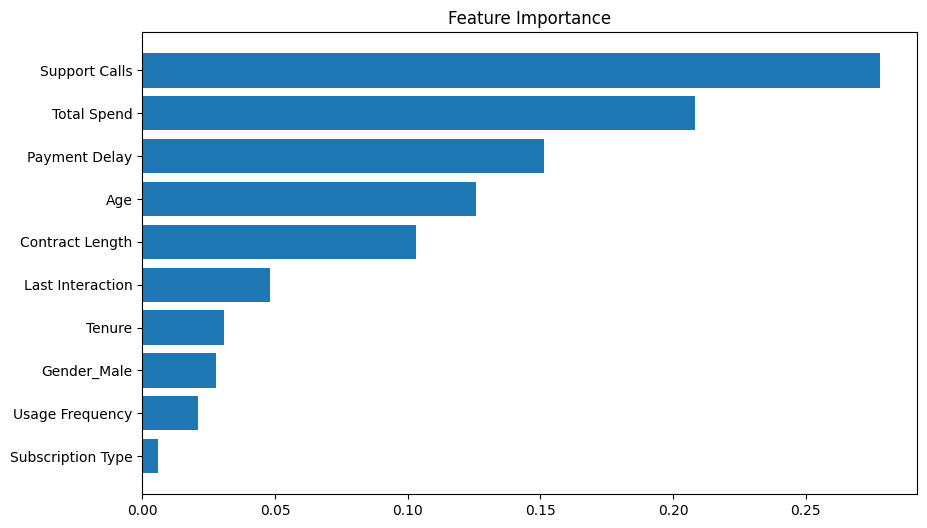

In [98]:
model = get_model(best_model_name)

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_

    feat_imp = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp["Feature"], feat_imp["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.show()
else:
    print("This model does not support feature importance")

##### Test Accuracy

In [99]:
model = get_model(best_model_name)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"{best_model_name} Test Accuracy: {acc:.2f}")

Random Forest Test Accuracy: 0.94


#### Saveing Our Models

In [101]:
import joblib

joblib.dump(model, 'Best_Model.pkl')
joblib.dump(scaler, 'Scaler.pkl')
joblib.dump(oe, 'Ordinal_Encoder.pkl')
joblib.dump(ohe, 'One_Hot_Encoder.pkl')

['One_Hot_Encoder.pkl']

#### Test Function

In [4]:
import pandas as pd
import joblib

# Load everything once (better practice)
model = joblib.load("Best_Model.pkl")
scaler = joblib.load("Scaler.pkl")
ohe = joblib.load("One_Hot_Encoder.pkl")
oe = joblib.load("Ordinal_Encoder.pkl")

def predict_customer(data):
    df = pd.DataFrame([data])

    # Columns
    num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                'Payment Delay', 'Total Spend', 'Last Interaction']
    
    ordinal_cols = ['Subscription Type', 'Contract Length']
    onehot_cols = ['Gender']

    # Step 1: Scale numeric
    df[num_cols] = scaler.transform(df[num_cols])

    # Step 2: Encode ordinal
    df[ordinal_cols] = oe.transform(df[ordinal_cols])

    # Step 3: One-hot encode
    ohe_df = pd.DataFrame(
        ohe.transform(df[onehot_cols]),
        columns = ohe.get_feature_names_out(onehot_cols)
    )

    df = pd.concat([df.drop(columns=onehot_cols), ohe_df], axis=1)

    # Step 4: Predict
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0]

    return pred, prob


# Test
pred, prob = predict_customer(Test_df)

print("Prediction:", pred)
print("Probability:", prob)

Prediction: 1.0
Probability: [0. 1.]
